<a href="https://colab.research.google.com/github/pejmanrasti/traitement_des_signaux_M2-/blob/main/06_Neyman_Pearson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neyman–Pearson (NP) Hypothesis Testing — Complete Python Tutorial

This notebook covers:

1. Neyman–Pearson lemma and the Likelihood Ratio Test (LRT)
2. Designing a detector with prescribed false alarm probability $(P_{FA}=\alpha)$
3. Computing $(P_D)$ and $(P_M = 1 - P_D)$
4. ROC curves and Monte–Carlo validation
5. Extension to $(N)$ samples (sample-mean detector)

We focus on the classical Gaussian detection problem:
- $(H_0)$: noise only
- $(H_1)$: signal + noise

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Try SciPy for accurate Normal CDF / inverse CDF.
# If SciPy is not available, we will fall back to math.erfc approximations for Q,
# but inverse-Q will be harder without SciPy.
try:
    from scipy.stats import norm
    SCIPY_AVAILABLE = True
except Exception:
    import math
    SCIPY_AVAILABLE = False

print("SciPy available:", SCIPY_AVAILABLE)


def Q(x):
    """
    Q-function: Q(x) = P(Z > x), where Z ~ N(0,1)
    """
    x = np.asarray(x)
    if SCIPY_AVAILABLE:
        return norm.sf(x)              # sf = 1 - cdf
    else:
        # Q(x) = 0.5 * erfc(x / sqrt(2))
        return 0.5 * np.vectorize(math.erfc)(x / np.sqrt(2))


def Qinv(p):
    """
    Inverse Q-function: returns x such that Q(x) = p.
    Requires SciPy for accurate inverse survival function.
    """
    if not SCIPY_AVAILABLE:
        raise RuntimeError("Qinv requires SciPy. Install scipy or use a lookup table.")
    return norm.isf(p)  # inverse survival function


def standardize(x, mean, var):
    """
    Convert X ~ N(mean, var) to Z ~ N(0,1): Z = (X - mean) / sqrt(var)
    """
    return (x - mean) / np.sqrt(var)

SciPy available: True


## Neyman–Pearson Lemma (Core idea)

We test two **simple hypotheses**:

- H0: parameter/value is exactly θ0
- H1: parameter/value is exactly θ1

The Neyman–Pearson lemma says:

> Among all tests whose false alarm probability is at most α,
> the most powerful test (highest detection probability) is the Likelihood Ratio Test (LRT):

$[
T(x) = \frac{p(x;H_1)}{p(x;H_0)} \gtrless_{\;H_0}^{\;H_1} \eta
]$

Then choose threshold η so that:

$[
P_{FA} = P(T(x) > \eta \mid H_0) = \alpha
]$

Very often the LRT is monotone in a simpler statistic (e.g., x itself),
so we can write an equivalent test:

$[
x \gtrless_{\;H_0}^{\;H_1} \gamma
]$

This notebook shows how to do all of this in Python.

## Problem A: One sample, Gaussian mean shift

Observation: \(x \sim \mathcal{N}(\mu, \sigma^2)\) with known variance.

Hypotheses:
- H0: μ = μ0
- H1: μ = μ1

In many detection problems, this corresponds to:
- H0: noise-only (mean μ0)
- H1: signal+noise (mean μ1)

We will implement:
1) the LRT,
2) the equivalent threshold on x,
3) P_FA, P_D, P_M,
4) ROC curves,
5) Monte-Carlo validation.

In [ ]:
def lrt_gaussian_mean_shift(x, mu0, mu1, var):
    """
    Likelihood ratio T(x) = p(x|H1) / p(x|H0) for Gaussian with known var.
    Returns T(x).
    """
    # p(x|mu) ∝ exp(-(x-mu)^2/(2var))
    # Ratio => exp( -((x-mu1)^2-(x-mu0)^2)/(2var) )
    return np.exp(-(((x - mu1)**2) - ((x - mu0)**2)) / (2 * var))


def equivalent_x_threshold(mu0, mu1, var, eta):
    """
    Convert LRT threshold eta into x-threshold gamma, assuming mu1 > mu0.
    For Gaussian mean shift, log LRT is linear in x.
    """
    # log T(x) = -((x-mu1)^2-(x-mu0)^2)/(2var)
    # Expand difference:
    # (x-mu1)^2 - (x-mu0)^2 = (x^2 - 2mu1 x + mu1^2) - (x^2 - 2mu0 x + mu0^2)
    # = -2(mu1-mu0)x + (mu1^2 - mu0^2)
    # log T(x) = - ( -2(mu1-mu0)x + (mu1^2-mu0^2) ) / (2var)
    #         = (mu1-mu0)x/var - (mu1^2 - mu0^2)/(2var)
    # Compare log T(x) > log eta:
    # (mu1-mu0)x/var > log eta + (mu1^2-mu0^2)/(2var)
    # x > [var*log eta + (mu1^2-mu0^2)/2] / (mu1-mu0)
    if mu1 == mu0:
        raise ValueError("mu1 must differ from mu0 for a meaningful test.")
    if mu1 < mu0:
        # inequality direction flips if mu1 < mu0 (rare in detection; still possible)
        raise ValueError("This helper assumes mu1 > mu0. Handle mu1 < mu0 separately.")
    gamma = (var * np.log(eta) + 0.5 * (mu1**2 - mu0**2)) / (mu1 - mu0)
    return gamma


def p_fa_pd_for_gamma(gamma, mu0, mu1, var):
    """
    Compute P_FA and P_D for threshold test: decide H1 if x > gamma,
    where under H0: x ~ N(mu0, var), under H1: x ~ N(mu1, var).
    """
    # P_FA = P(x > gamma | H0) = Q((gamma - mu0)/sqrt(var))
    # P_D  = P(x > gamma | H1) = Q((gamma - mu1)/sqrt(var))
    p_fa = Q((gamma - mu0) / np.sqrt(var))
    p_d  = Q((gamma - mu1) / np.sqrt(var))
    p_m  = 1 - p_d
    return p_fa, p_d, p_m

### NP threshold design (key step)

If the final test is `decide H1 if x > γ`, then:

$[
P_{FA} = P(x > \gamma | H_0) = Q\left(\frac{\gamma-\mu_0}{\sigma}\right)
]-

Set $(P_{FA}=\alpha)$:

$[
Q\left(\frac{\gamma-\mu_0}{\sigma}\right)=\alpha
\Rightarrow
\frac{\gamma-\mu_0}{\sigma} = Q^{-1}(\alpha)
\Rightarrow
\gamma = \mu_0 + \sigma Q^{-1}(\alpha)
]$

This is the classic NP “choose threshold from α” formula.

In [ ]:
def gamma_from_alpha(alpha, mu0, var):
    """
    NP design: choose gamma so that P_FA = alpha for test x > gamma under H0~N(mu0,var).
    gamma = mu0 + sqrt(var) * Qinv(alpha)
    """
    return mu0 + np.sqrt(var) * Qinv(alpha)

In [ ]:
mu0, mu1, var = 0.0, 1.0, 1.0
alpha = 1e-2  # desired false alarm

gamma = gamma_from_alpha(alpha, mu0, var)
p_fa, p_d, p_m = p_fa_pd_for_gamma(gamma, mu0, mu1, var)

gamma, p_fa, p_d, p_m

(np.float64(2.3263478740408408),
 np.float64(0.01),
 np.float64(0.09236224807369403),
 np.float64(0.9076377519263059))

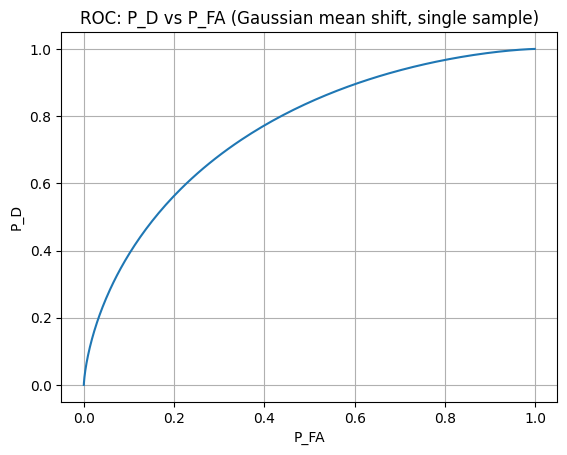

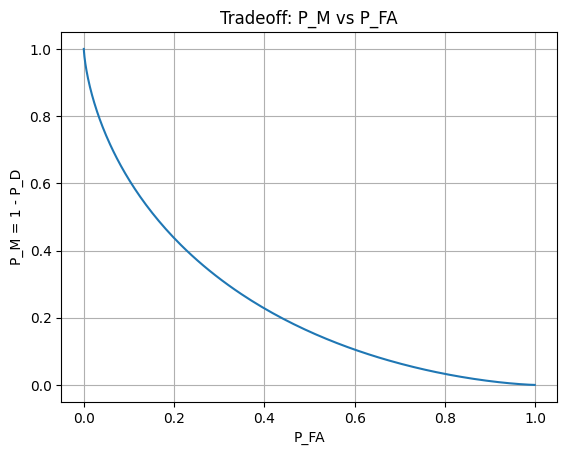

In [ ]:
# ROC via sweeping gamma
gammas = np.linspace(-3, 5, 400)
PFA = np.zeros_like(gammas)
PD  = np.zeros_like(gammas)
PM  = np.zeros_like(gammas)

for i, g in enumerate(gammas):
    PFA[i], PD[i], PM[i] = p_fa_pd_for_gamma(g, mu0, mu1, var)

plt.figure()
plt.plot(PFA, PD)
plt.xlabel("P_FA")
plt.ylabel("P_D")
plt.title("ROC: P_D vs P_FA (Gaussian mean shift, single sample)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(PFA, PM)
plt.xlabel("P_FA")
plt.ylabel("P_M = 1 - P_D")
plt.title("Tradeoff: P_M vs P_FA")
plt.grid(True)
plt.show()

In [ ]:
def simulate_detector(mu0, mu1, var, gamma, Nmc=200_000, seed=0):
    rng = np.random.default_rng(seed)
    # Under H0
    x0 = rng.normal(loc=mu0, scale=np.sqrt(var), size=Nmc)
    # Under H1
    x1 = rng.normal(loc=mu1, scale=np.sqrt(var), size=Nmc)

    # decision: H1 if x > gamma
    d0 = (x0 > gamma)  # false alarms under H0
    d1 = (x1 > gamma)  # detections under H1

    p_fa_hat = d0.mean()
    p_d_hat  = d1.mean()
    p_m_hat  = 1 - p_d_hat
    return p_fa_hat, p_d_hat, p_m_hat


p_fa_hat, p_d_hat, p_m_hat = simulate_detector(mu0, mu1, var, gamma)
print("Theoretical  P_FA, P_D, P_M:", p_fa, p_d, p_m)
print("Simulated    P_FA, P_D, P_M:", p_fa_hat, p_d_hat, p_m_hat)

Theoretical  P_FA, P_D, P_M: 0.01 0.09236224807369403 0.9076377519263059
Simulated    P_FA, P_D, P_M: 0.01015 0.092665 0.907335


## Problem B: H0 = noise, H1 = signal + noise

Model:
- H0: x = w
- H1: x = A + w
where w ~ N(0, σ²) is noise.

So:
- Under H0: x ~ N(0, σ²)
- Under H1: x ~ N(A, σ²)

This is exactly a Gaussian mean shift with:
μ0 = 0, μ1 = A.

In [ ]:
A = 1.2
var = 1.5
mu0, mu1 = 0.0, A
alpha = 5e-3

gamma = gamma_from_alpha(alpha, mu0, var)
p_fa, p_d, p_m = p_fa_pd_for_gamma(gamma, mu0, mu1, var)

print("gamma:", gamma)
print("P_FA:", p_fa)
print("P_D :", p_d)
print("P_M :", p_m)

# Validate by Monte Carlo
p_fa_hat, p_d_hat, p_m_hat = simulate_detector(mu0, mu1, var, gamma, Nmc=400_000, seed=1)
print("Simulated P_FA, P_D, P_M:", p_fa_hat, p_d_hat, p_m_hat)

gamma: 3.1547337291016846
P_FA: 0.004999999999999998
P_D : 0.05524066753831186
P_M : 0.9447593324616881
Simulated P_FA, P_D, P_M: 0.004875 0.055165 0.944835


### Quick performance intuition

Single-sample detection quality depends strongly on the normalized separation:

$[
d' = \frac{\mu_1 - \mu_0}{\sigma}
]$

Bigger `d'` => distributions overlap less => ROC improves.

For signal+noise with μ0=0, μ1=A:
$[
d' = \frac{A}{\sigma}
]$

In [ ]:
dprime = (mu1 - mu0) / np.sqrt(var)
snr_linear = (A**2) / var
snr_db = 10*np.log10(snr_linear)

print("d' =", dprime)
print("SNR = A^2/var =", snr_linear, "=>", snr_db, "dB")

d' = 0.9797958971132713
SNR = A^2/var = 0.96 => -0.17728766960431602 dB


## Extension: N i.i.d. samples (big upgrade)

Now observe N samples:

- H0: x[n] = w[n]
- H1: x[n] = A + w[n]
with w[n] ~ N(0, σ²), independent.

A sufficient statistic is the sample mean:

$[
\bar{x} = \frac{1}{N}\sum_{n=0}^{N-1} x[n]
]$

Distributions:

- Under H0: \(\bar{x} \sim N(0, \sigma^2/N)\)
- Under H1: \(\bar{x} \sim N(A, \sigma^2/N)\)

So the NP test becomes:

$[
\bar{x} \gtrless \gamma_N
]$

and the threshold for a target α is:

$[
\gamma_N = 0 + \sqrt{\sigma^2/N}\, Q^{-1}(\alpha)
]$

Detection probability becomes:

$[
P_D = Q\left(\frac{\gamma_N - A}{\sqrt{\sigma^2/N}}\right)
]$

This shows why increasing N drastically improves detection.

In [ ]:
def gamma_from_alpha_mean(alpha, var, N):
    """
    Threshold for test on xbar under H0: xbar ~ N(0, var/N)
    """
    return np.sqrt(var / N) * Qinv(alpha)

def pd_for_mean_threshold(gammaN, A, var, N):
    """
    For xbar test: xbar ~ N(A, var/N) under H1
    """
    return Q((gammaN - A) / np.sqrt(var / N))

alphas = [1e-1, 1e-2, 1e-3, 5e-3]
N_list = [1, 5, 20, 100]

print("A =", A, "var =", var)
for N in N_list:
    print("\nN =", N)
    for a in alphas:
        gN = gamma_from_alpha_mean(a, var, N)
        PD = pd_for_mean_threshold(gN, A, var, N)
        print(f"  alpha={a:g} -> gammaN={gN:.4f}, PD={PD:.4f}, PM={1-PD:.4f}")

A = 1.2 var = 1.5

N = 1
  alpha=0.1 -> gammaN=1.5696, PD=0.3814, PM=0.6186
  alpha=0.01 -> gammaN=2.8492, PD=0.0891, PM=0.9109
  alpha=0.001 -> gammaN=3.7847, PD=0.0174, PM=0.9826
  alpha=0.005 -> gammaN=3.1547, PD=0.0552, PM=0.9448

N = 5
  alpha=0.1 -> gammaN=0.7019, PD=0.8184, PM=0.1816
  alpha=0.01 -> gammaN=1.2742, PD=0.4461, PM=0.5539
  alpha=0.001 -> gammaN=1.6926, PD=0.1842, PM=0.8158
  alpha=0.005 -> gammaN=1.4108, PD=0.3501, PM=0.6499

N = 20
  alpha=0.1 -> gammaN=0.3510, PD=0.9990, PM=0.0010
  alpha=0.01 -> gammaN=0.6371, PD=0.9801, PM=0.0199
  alpha=0.001 -> gammaN=0.8463, PD=0.9017, PM=0.0983
  alpha=0.005 -> gammaN=0.7054, PD=0.9645, PM=0.0355

N = 100
  alpha=0.1 -> gammaN=0.1570, PD=1.0000, PM=0.0000
  alpha=0.01 -> gammaN=0.2849, PD=1.0000, PM=0.0000
  alpha=0.001 -> gammaN=0.3785, PD=1.0000, PM=0.0000
  alpha=0.005 -> gammaN=0.3155, PD=1.0000, PM=0.0000


In [ ]:
def simulate_detector_mean(A, var, N, gammaN, Nmc=200_000, seed=0):
    rng = np.random.default_rng(seed)

    # H0: x = w
    x0 = rng.normal(0.0, np.sqrt(var), size=(Nmc, N))
    # H1: x = A + w
    x1 = rng.normal(A, np.sqrt(var), size=(Nmc, N))

    xbar0 = x0.mean(axis=1)
    xbar1 = x1.mean(axis=1)

    d0 = (xbar0 > gammaN)
    d1 = (xbar1 > gammaN)

    return d0.mean(), d1.mean(), 1 - d1.mean()


alpha = 5e-3
for N in [1, 10, 50]:
    gammaN = gamma_from_alpha_mean(alpha, var, N)
    p_fa_th = alpha
    p_d_th  = pd_for_mean_threshold(gammaN, A, var, N)

    p_fa_hat, p_d_hat, p_m_hat = simulate_detector_mean(A, var, N, gammaN, Nmc=300_000, seed=2)

    print(f"\nN={N}")
    print("theory   P_FA, P_D, P_M:", p_fa_th, p_d_th, 1-p_d_th)
    print("simulated P_FA, P_D, P_M:", p_fa_hat, p_d_hat, p_m_hat)


N=1
theory   P_FA, P_D, P_M: 0.005 0.05524066753831186 0.9447593324616881
simulated P_FA, P_D, P_M: 0.004873333333333334 0.0558 0.9442

N=10
theory   P_FA, P_D, P_M: 0.005 0.6993588446422471 0.30064115535775293
simulated P_FA, P_D, P_M: 0.00524 0.6994633333333333 0.3005366666666667

N=50
theory   P_FA, P_D, P_M: 0.005 0.9999932664341812 6.733565818817233e-06
simulated P_FA, P_D, P_M: 0.00509 0.9999966666666666 3.3333333333551707e-06


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# If SciPy is available, we can use norm for exact tails; otherwise we assume you've already defined Q, Qinv.
try:
    from scipy.stats import norm
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

def auc_trapz(pfa, pd):
    """
    Compute AUC using trapezoidal integration.
    Sorts by P_FA to ensure correct integration.
    """
    pfa = np.asarray(pfa)
    pd = np.asarray(pd)

    order = np.argsort(pfa)
    pfa_sorted = pfa[order]
    pd_sorted = pd[order]

    # Remove duplicates in P_FA (optional, for numerical stability)
    # We'll keep the max PD for same PFA if it happens.
    # (Not strictly necessary if pfa is strictly monotone)
    return np.trapz(pd_sorted, pfa_sorted)

def roc_theory_gaussian_threshold(mu0, mu1, var, gammas):
    """
    For test: decide H1 if x > gamma
    Under H0: x ~ N(mu0,var), Under H1: x ~ N(mu1,var)
    Returns arrays (PFA, PD) as gamma is swept.
    """
    sigma = np.sqrt(var)
    if SCIPY_AVAILABLE:
        PFA = norm.sf((gammas - mu0) / sigma)
        PD  = norm.sf((gammas - mu1) / sigma)
    else:
        # assumes Q is already defined
        PFA = Q((gammas - mu0) / sigma)
        PD  = Q((gammas - mu1) / sigma)
    return PFA, PD

def roc_simulation_threshold(mu0, mu1, var, gammas, Nmc=200_000, seed=0):
    """
    Empirical ROC for test x > gamma using Monte Carlo samples.
    """
    rng = np.random.default_rng(seed)
    x0 = rng.normal(mu0, np.sqrt(var), size=Nmc)  # H0 samples
    x1 = rng.normal(mu1, np.sqrt(var), size=Nmc)  # H1 samples

    PFA = np.array([(x0 > g).mean() for g in gammas])
    PD  = np.array([(x1 > g).mean() for g in gammas])
    return PFA, PD

/tmp/ipython-input-740657606.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(pd_sorted, pfa_sorted)


Single-sample ROC AUC (theory): 0.7046461464911009
Single-sample ROC AUC (MC)    : 0.7057723740111111


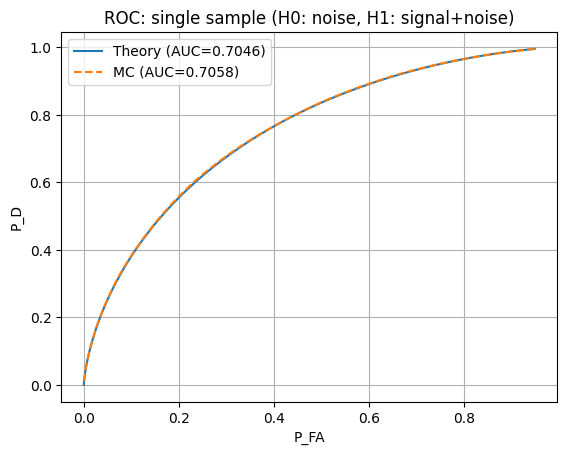

In [ ]:
# Exercise 2 parameters
A = 1.2
var = 1.5
mu0, mu1 = 0.0, A

# Sweep thresholds (wide enough range)
gammas = np.linspace(-2, 8, 600)

# Theoretical ROC
PFA_th, PD_th = roc_theory_gaussian_threshold(mu0, mu1, var, gammas)
AUC_th = auc_trapz(PFA_th, PD_th)

# Simulated ROC
PFA_mc, PD_mc = roc_simulation_threshold(mu0, mu1, var, gammas, Nmc=300_000, seed=1)
AUC_mc = auc_trapz(PFA_mc, PD_mc)

print("Single-sample ROC AUC (theory):", AUC_th)
print("Single-sample ROC AUC (MC)    :", AUC_mc)

# Plot ROC
plt.figure()
plt.plot(PFA_th, PD_th, label=f"Theory (AUC={AUC_th:.4f})")
plt.plot(PFA_mc, PD_mc, "--", label=f"MC (AUC={AUC_mc:.4f})")
plt.xlabel("P_FA")
plt.ylabel("P_D")
plt.title("ROC: single sample (H0: noise, H1: signal+noise)")
plt.grid(True)
plt.legend()
plt.show()

/tmp/ipython-input-740657606.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(pd_sorted, pfa_sorted)


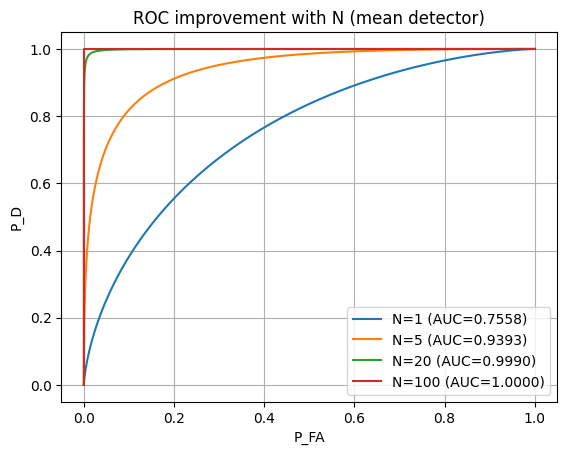

In [ ]:
def roc_theory_mean_detector(A, var, N, gammas):
    """
    ROC for mean detector: decide H1 if xbar > gamma
    Under H0: xbar ~ N(0, var/N)
    Under H1: xbar ~ N(A, var/N)
    """
    mu0, mu1 = 0.0, A
    var_eff = var / N
    return roc_theory_gaussian_threshold(mu0, mu1, var_eff, gammas)

def roc_simulation_mean_detector(A, var, N, gammas, Nmc=200_000, seed=0):
    rng = np.random.default_rng(seed)
    x0 = rng.normal(0.0, np.sqrt(var), size=(Nmc, N))   # H0
    x1 = rng.normal(A,   np.sqrt(var), size=(Nmc, N))   # H1
    xbar0 = x0.mean(axis=1)
    xbar1 = x1.mean(axis=1)

    PFA = np.array([(xbar0 > g).mean() for g in gammas])
    PD  = np.array([(xbar1 > g).mean() for g in gammas])
    return PFA, PD

# Compare AUC as N increases
N_list = [1, 5, 20, 100]
plt.figure()

for N in N_list:
    # choose gamma sweep appropriate for xbar scale (std shrinks with sqrt(N))
    std_eff = np.sqrt(var / N)
    gammasN = np.linspace(-4*std_eff, A + 6*std_eff, 600)

    PFA_th, PD_th = roc_theory_mean_detector(A, var, N, gammasN)
    AUC_th = auc_trapz(PFA_th, PD_th)

    plt.plot(PFA_th, PD_th, label=f"N={N} (AUC={AUC_th:.4f})")

plt.xlabel("P_FA")
plt.ylabel("P_D")
plt.title("ROC improvement with N (mean detector)")
plt.grid(True)
plt.legend()
plt.show()